In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
import akshare as ak
import matplotlib.pyplot as plt
import sys

project_root = Path.cwd().parent
src_path = project_root / "src"
sys.path.append(str(src_path))
from metrics import calc_stock_metrics, print_metrics, plot_metrics
from get_single_stock import get_single_stock
from batch_stock_analysis import get_batch_stock, batch_stock_analysis

In [2]:
stock_list = ["000001", "000002", "600519", "600036", "300750"]
start_date = "20150101"
end_date = pd.Timestamp.today().strftime("%Y%m%d")
# =========================
# 7. 打印结果
# =========================
df = get_batch_stock(stock_list=stock_list, start_date=start_date, end_date=end_date)

display_df = batch_stock_analysis(stock_list=stock_list)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("\n风险收益排名表：")
print(display_df)

正在获取 000001...
尝试使用东方财富接口获取 000001...
东方财富接口失败：000001
ProxyError HTTPSConnectionPool(host='push2his.eastmoney.com', port=443): Max retries exceeded with url: /api/qt/stock/kline/get?fields1=f1%2Cf2%2Cf3%2Cf4%2Cf5%2Cf6&fields2=f51%2Cf52%2Cf53%2Cf54%2Cf55%2Cf56%2Cf57%2Cf58%2Cf59%2Cf60%2Cf61%2Cf116&ut=7eea3edcaed734bea9cbfc24409ed989&klt=101&fqt=1&secid=0.000001&beg=20150101&end=20260711 (Caused by ProxyError('Unable to connect to proxy', RemoteDisconnected('Remote end closed connection without response')))
尝试切换到新浪接口获取 000001...
新浪接口成功：000001
正在获取 000002...
尝试使用东方财富接口获取 000002...
东方财富接口失败：000002
ProxyError HTTPSConnectionPool(host='push2his.eastmoney.com', port=443): Max retries exceeded with url: /api/qt/stock/kline/get?fields1=f1%2Cf2%2Cf3%2Cf4%2Cf5%2Cf6&fields2=f51%2Cf52%2Cf53%2Cf54%2Cf55%2Cf56%2Cf57%2Cf58%2Cf59%2Cf60%2Cf61%2Cf116&ut=7eea3edcaed734bea9cbfc24409ed989&klt=101&fqt=1&secid=0.000002&beg=20150101&end=20260711 (Caused by ProxyError('Unable to connect to proxy', RemoteDisconne

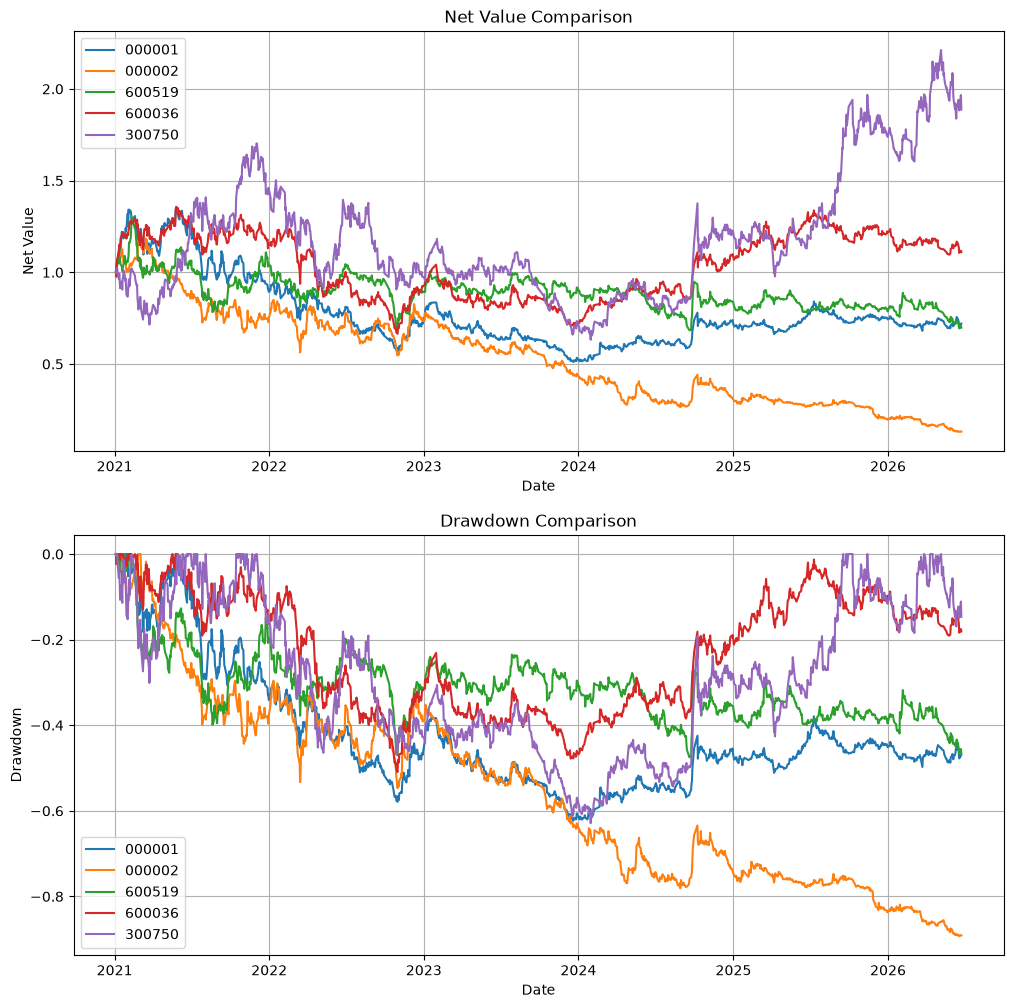

In [ ]:
PROCESSED_DIR = project_root / "data" / "processed"

stock_list = ["000001", "000002", "600519", "600036", "300750"]
plt.figure(figsize=(12, 12))
plt.subplot(211)

for symbol in stock_list:
    file_path = PROCESSED_DIR / f"{symbol}_clean.csv"
    df_stock = pd.read_csv(file_path)

    df_stock["date"] = pd.to_datetime(df_stock["date"])
    df_stock = df_stock.sort_values("date").reset_index(drop=True)

    df_stock["daily_return"] = df_stock["close"].pct_change().fillna(0)
    df_stock["net_value"] = (1 + df_stock["daily_return"]).cumprod()

    plt.plot(df_stock["date"], df_stock["net_value"], label=symbol)

plt.title("Net Value Comparison")
plt.xlabel("Date")
plt.ylabel("Net Value")
plt.grid(True)
plt.legend()

plt.subplot(212)
for symbol in stock_list:
    file_path = PROCESSED_DIR / f"{symbol}_clean.csv"
    df_stock = pd.read_csv(file_path)

    df_stock["date"] = pd.to_datetime(df_stock["date"])
    df_stock = df_stock.sort_values("date").reset_index(drop=True)

    df_stock["daily_return"] = df_stock["close"].pct_change().fillna(0)
    df_stock["net_value"] = (1 + df_stock["daily_return"]).cumprod()

    df_stock["rolling_max"] = df_stock["net_value"].cummax()
    df_stock["drawdown"] = df_stock["net_value"] / df_stock["rolling_max"] - 1

    plt.plot(df_stock["date"], df_stock["drawdown"], label=symbol)

plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.legend()
plt.show()